In [96]:
import pandas as pd
import numpy as np

In [97]:
df=pd.read_excel("online_retail_II.xlsx")
clean_df=df.copy()

In [98]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom


# Exploratory Data Analysis

In [99]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

## Dataset Info

In [100]:
df.shape

(525461, 8)

In [101]:
df.isnull().mean()*100

Invoice         0.000000
StockCode       0.000000
Description     0.557225
Quantity        0.000000
InvoiceDate     0.000000
Price           0.000000
Customer ID    20.539488
Country         0.000000
dtype: float64

In [102]:
df.nunique()

Invoice        28816
StockCode       4632
Description     4681
Quantity         825
InvoiceDate    25296
Price           1606
Customer ID     4383
Country           40
dtype: int64

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [104]:
df.sample(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
390555,526916,22502,PICNIC BASKET WICKER SMALL,2,2010-10-13 16:20:00,8.47,NaN,United Kingdom
173892,505860,22525,CHILDRENS GARDEN GLOVES PINK,1,2010-04-26 13:18:00,2.51,NaN,United Kingdom
18535,490954,72800F,4 IVORY DINNER CANDLES GOLD FLOCK,1,2009-12-08 15:00:00,2.55,15924.0,United Kingdom
106242,499517,20981,12 PENCILS TALL TUBE WOODLAND,12,2010-03-01 09:58:00,0.85,12598.0,France
220898,510814,22616,PACK OF 12 LONDON TISSUES,12,2010-06-03 19:24:00,0.29,13230.0,United Kingdom


In [105]:
df.select_dtypes(exclude=object)

,Quantity,InvoiceDate,Price,Customer ID
0,12,2009-12-01 07:45:00,6.95,13085.0
1,12,2009-12-01 07:45:00,6.75,13085.0
2,12,2009-12-01 07:45:00,6.75,13085.0
3,48,2009-12-01 07:45:00,2.10,13085.0
4,24,2009-12-01 07:45:00,1.25,13085.0
...,...,...,...,...
525456,2,2010-12-09 20:01:00,2.95,17530.0
525457,1,2010-12-09 20:01:00,3.75,17530.0
525458,1,2010-12-09 20:01:00,3.75,17530.0
525459,2,2010-12-09 20:01:00,3.75,17530.0


In [106]:
df.select_dtypes(include=object)

,Invoice,StockCode,Description,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,United Kingdom
...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,United Kingdom
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,United Kingdom
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,United Kingdom
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,United Kingdom


***
## Basic EDA

In [107]:
country_without_custid=df[df["Customer ID"].isnull()].groupby("Country")["Country"].value_counts().index

In [108]:
country_with_custid=df["Country"][~df["Country"].isin(country_without_custid)].unique()

In [109]:
df[df["Customer ID"].isnull()]["InvoiceDate"].min()

Timestamp('2009-12-01 10:52:00')

In [110]:
df["InvoiceDate"].min()

Timestamp('2009-12-01 07:45:00')

In [111]:
df[df["Price"]<0]
# this column can be dangerous for us for customer churn prediction because it is outlets data

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom


In [112]:
(df["Quantity"]<0).mean()*100 
# this is returned products

np.float64(2.3457497321399687)

In [113]:
df[df["Quantity"] < 0][["Invoice","Quantity"]].groupby("Invoice")["Quantity"].sum().reset_index()

,Invoice,Quantity
0,489463,-240
1,489464,-96
2,489467,-192
3,489521,-50
4,489655,-44
...,...,...
6707,C538121,-1
6708,C538122,-1
6709,C538123,-4
6710,C538124,-6


In [114]:
df["Invoice"].nunique()

28816

In [115]:
df[df["Invoice"].astype(str).str.startswith("C")]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
524695,C538123,22956,36 FOIL HEART CAKE CASES,-2,2010-12-09 15:41:00,2.10,12605.0,Germany
524696,C538124,M,Manual,-4,2010-12-09 15:43:00,0.50,15329.0,United Kingdom
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329.0,United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329.0,United Kingdom


In [116]:
df.duplicated().sum()

np.int64(6865)

In [117]:
df[df.duplicated(keep=False)].head(20).sort_values("Description")

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
658,489529,22036,DINOSAUR BIRTHDAY CARD,12,2009-12-01 11:51:00,0.42,17984.0,United Kingdom
656,489529,22036,DINOSAUR BIRTHDAY CARD,12,2009-12-01 11:51:00,0.42,17984.0,United Kingdom
628,489529,48129,DOOR MAT TOPIARY,1,2009-12-01 11:51:00,6.75,17984.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
384,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
383,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
634,489529,22028,PENNY FARTHING BIRTHDAY CARD,12,2009-12-01 11:51:00,0.42,17984.0,United Kingdom


In [118]:
df.drop_duplicates(inplace=True)

In [119]:
df["Customer ID"].nunique()

4383

In [120]:
df["Customer ID"][df["Customer ID"].notnull()].nunique()

4383

Since NAN values belongs to anonymous Customers or anonymous Description may be as of Store accounting.

In [121]:
df.dropna(subset=["Customer ID"],inplace=True)
df.shape

(410763, 8)

In [122]:
df=df[~df["Description"].astype(str).str.contains("Adjust",case=False)]

In [123]:
df.shape

(410699, 8)

In [124]:
df["Total"]=df["Price"]*df["Quantity"]

C:\Users\chand\AppData\Local\Temp\ipykernel_12056\2972189914.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Total"]=df["Price"]*df["Quantity"]


***
***
# DATA CREATION FOR TRAINING

***
## Feature Engineering

In [125]:
tf=pd.DataFrame()
tf=df.groupby("Customer ID")["InvoiceDate"].max().reset_index()

In [126]:
tf["Recency"]=df["InvoiceDate"].max()-tf["InvoiceDate"]

In [127]:
tf["Recency"]=tf["Recency"].dt.days

In [128]:
tf

,Customer ID,InvoiceDate,Recency
0,12346.0,2010-10-04 16:33:00,66
1,12347.0,2010-12-07 14:57:00,2
2,12348.0,2010-09-27 14:59:00,73
3,12349.0,2010-10-28 08:23:00,42
4,12351.0,2010-11-29 15:23:00,10
...,...,...,...
4360,18283.0,2010-11-22 15:30:00,17
4361,18284.0,2010-10-06 12:31:00,64
4362,18285.0,2010-02-17 10:24:00,295
4363,18286.0,2010-08-20 11:57:00,111


In [129]:
tf=pd.merge(tf,df.groupby("Customer ID")["Invoice"].nunique().reset_index(),on="Customer ID",how="left")

In [130]:
tf.rename(columns={"Invoice":"Total Invoice"},inplace=True)

In [131]:
tf=pd.merge(tf,df.groupby("Customer ID")["Total"].sum().reset_index(),on="Customer ID",how="left")

In [132]:
tf["Monetary"]=tf["Total"]

In [133]:
tf.drop(columns=["Total","InvoiceDate"],inplace=True)

In [134]:
tf["Avg_expenses_per_invoice"]=np.round(tf["Monetary"]/tf["Total Invoice"],2)

In [135]:
tf

,Customer ID,Recency,Total Invoice,Monetary,Avg_expenses_per_invoice
0,12346.0,66,14,51.76,3.70
1,12347.0,2,2,1323.32,661.66
2,12348.0,73,1,222.16,222.16
3,12349.0,42,4,2646.99,661.75
4,12351.0,10,1,300.93,300.93
...,...,...,...,...,...
4360,18283.0,17,6,619.37,103.23
4361,18284.0,64,2,436.68,218.34
4362,18285.0,295,1,427.00,427.00
4363,18286.0,111,3,1188.43,396.14


In [136]:
customer_lifespan=df.groupby("Customer ID")["InvoiceDate"].apply(lambda x:x.max()-x.min()).dt.days.reset_index()

In [137]:
tf=pd.merge(tf,customer_lifespan,on="Customer ID",how="left")

In [138]:
tf.rename(columns={"InvoiceDate_y": "customer_span"},inplace=True)

In [139]:
tf.rename(columns={"InvoiceDate": "customer_span"},inplace=True)

In [140]:
tf

,Customer ID,Recency,Total Invoice,Monetary,Avg_expenses_per_invoice,customer_span
0,12346.0,66,14,51.76,3.70,294
1,12347.0,2,2,1323.32,661.66,37
2,12348.0,73,1,222.16,222.16,0
3,12349.0,42,4,2646.99,661.75,327
4,12351.0,10,1,300.93,300.93,0
...,...,...,...,...,...,...
4360,18283.0,17,6,619.37,103.23,275
4361,18284.0,64,2,436.68,218.34,2
4362,18285.0,295,1,427.00,427.00,0
4363,18286.0,111,3,1188.43,396.14,247


In [141]:
df

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.40
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.00
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.80
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.00
...,...,...,...,...,...,...,...,...,...
525456,538171,22271,FELTCRAFT DOLL ROSIE,2,2010-12-09 20:01:00,2.95,17530.0,United Kingdom,5.90
525457,538171,22750,FELTCRAFT PRINCESS LOLA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525458,538171,22751,FELTCRAFT PRINCESS OLIVIA DOLL,1,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,3.75
525459,538171,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,2,2010-12-09 20:01:00,3.75,17530.0,United Kingdom,7.50


In [142]:
af=df[["Invoice","Customer ID","InvoiceDate"]]

In [143]:
af=af.groupby(["Invoice","Customer ID"])["InvoiceDate"].min().reset_index()

In [144]:
af = af.sort_values(
    ["Customer ID","InvoiceDate"]
)

In [145]:
af["Next_Date"]=af.groupby("Customer ID")["InvoiceDate"].shift(-1)

In [146]:
af["gap"]=(af["Next_Date"]-af["InvoiceDate"])

In [147]:
af["gap_days"] = af["gap"].dt.total_seconds()/(24*60*60)

In [148]:
af=af.groupby("Customer ID")["gap_days"].mean().reset_index()

In [149]:
tf=pd.merge(tf,af,on="Customer ID",how="left")

In [150]:
tf

,Customer ID,Recency,Total Invoice,Monetary,Avg_expenses_per_invoice,customer_span,gap_days
0,12346.0,66,14,51.76,3.70,294,22.640972
1,12347.0,2,2,1323.32,661.66,37,37.025694
2,12348.0,73,1,222.16,222.16,0,NaN
3,12349.0,42,4,2646.99,661.75,327,109.271759
4,12351.0,10,1,300.93,300.93,0,NaN
...,...,...,...,...,...,...,...
4360,18283.0,17,6,619.37,103.23,275,55.185278
4361,18284.0,64,2,436.68,218.34,2,2.040278
4362,18285.0,295,1,427.00,427.00,0,NaN
4363,18286.0,111,3,1188.43,396.14,247,123.525000


***
## Potential Churners

In [151]:
clean_tf=tf.copy()

In [152]:
tf=clean_tf

In [153]:
tf["gap_days"].isnull().sum()

np.int64(1253)

In [154]:
tf.shape[0]

4365

Out of 4,365 customers, 1,253 (28.7%) made only a single purchase during the observation period. This indicates that nearly one-third of customers did not return for a repeat purchase, highlighting a potential customer retention challenge.

**SO NOW WE WILL MAKE A POTENTIAL CHURN FOR THOSE CUSTOMER WHO VISITED ONLY ONCE ON THE BASIS OF RECENCY IF THERE RECENCY>2.5*QUANTILE(0.85) WE WILL CONSIDER THEM AS THE CUSTOMER IS A CHURN.**

In [155]:
threshold=tf["gap_days"].quantile(0.85)
global_gap=tf["gap_days"].median()

In [156]:
tf["Potential_Churn_By_single_visit"]=np.where((tf["Recency"]>2.5*threshold) & (tf["Total Invoice"]==1),1,0)

In [157]:
(
    (tf["Recency"] > 2.5*threshold) &
    (tf["Total Invoice"] == 1)
).sum()

np.int64(301)

In [158]:
tf["Potential_Churn_over_all"]=np.where(tf["Recency"]>0.85*(2*tf["gap_days"])+0.15*(global_gap),1,0)

In [159]:
tf["Potential_Churn_over_all"].value_counts()

Potential_Churn_over_all
0    3509
1     856
Name: count, dtype: int64

Since our overall churn have logic is very personalized and analytical.But the problem is when we do this Recency>gap_days for single visited gap_days is NAN so it would always return those customer as Not Churn so for final potential_churn we would have take "OR" of both Potential_Churn_over_all and Potential_Churn_By_single_visit

In [160]:
tf["Potential_Churn"]=np.where((tf["Potential_Churn_By_single_visit"]==1)
                              |
                              (tf["Potential_Churn_over_all"]==1),1,0)

In [161]:
tf.drop(columns=["Potential_Churn_By_single_visit","Potential_Churn_over_all"],inplace=True)

In [162]:
tf["Potential_Churn"].value_counts()

Potential_Churn
0    3208
1    1157
Name: count, dtype: int64

In [163]:
churn_rate = tf["Potential_Churn"].mean() * 100
print(f"Potential churn rate: {churn_rate:.2f}%")

Potential churn rate: 26.51%


# Customer Analytics & Churn Analysis - Key Findings #

# Customer-Level Feature Engineering

To better understand customer purchasing behavior, the transactional dataset was transformed into a customer-level dataset using the following features:

* **Recency** → Number of days since the customer's last purchase.
* **Total Invoice (Frequency)** → Total number of orders placed by the customer.
* **Monetary Value** → Total amount spent by the customer.
* **Average Expense per Invoice** → Average spending per order.
* **Average Purchase Gap** → Average number of days between consecutive purchases.

### Average Purchase Gap Calculation

Since the original dataset contains multiple product rows for a single invoice, invoice-level data was first created before calculating purchase gaps. Consecutive purchase dates were then compared for each customer to estimate their typical revisit cycle.

This feature helps capture customer buying habits more accurately than frequency alone.

---

# Single-Purchase Customer Analysis

During feature engineering, it was observed that many customers had only one purchase in the entire observation period.

### Findings

* Total Customers: **4,365**
* Customers with only one purchase: **1,253**
* Percentage of single-purchase customers: **28.7%**

This indicates that nearly one-third of customers made only one purchase during the observed period.

However, it would be incorrect to directly classify all these customers as churned because some of them may have purchased recently and simply have not had enough time to return.

---

# Potential Churn Analysis

A behavior-based churn identification approach was developed instead of relying solely on recency.

## For Repeat Customers

Each customer's current inactivity period (**Recency**) was compared against an expected purchase cycle derived from both:

1. The customer's own historical purchasing behavior.
2. The overall purchasing behavior observed across all customers.

### Dynamic Purchase Gap Threshold

A weighted purchase-gap threshold was calculated as:

[
\text{Dynamic Gap Threshold}
============================

0.85 \times \text{Customer Average Purchase Gap}
+
0.15 \times \text{Global Average Purchase Gap}
]

where:

* **Customer Average Purchase Gap** represents the customer's typical time between purchases.
* **Global Average Purchase Gap** represents the overall average revisit pattern across all customers.

The weighted approach was introduced to improve stability:

* Customers with unusually small purchase gaps are prevented from being classified as churned too quickly.
* Customers with unusually large purchase gaps are partially regularized toward the overall customer trend.
* The model retains personalization while incorporating broader business behavior.

A repeat customer was classified as a potential churn risk if:

[
\text{Recency}

>

2 \times \text{Dynamic Gap Threshold}
]

The additional multiplier acts as a buffer period, reducing the likelihood of falsely classifying customers who are only slightly late relative to their normal purchasing cycle.

---

## For Single-Purchase Customers

Customers with only one purchase do not have sufficient purchase history to calculate an individual purchase gap.

Therefore, a population-level benchmark was used.

The **85th percentile of customer purchase gaps** was selected as a conservative estimate of expected revisit behavior.

A single-purchase customer was classified as a potential churn risk if:

[
\text{Recency}

>

2.5 \times \left(\text{85th Percentile Purchase Gap}\right)
]

This approach reduces false positives and prevents recently acquired customers from being incorrectly classified as churned.

---

# Final Churn Identification

The final churn flag was created by combining:

* Potential churn among repeat customers.
* Potential churn among single-purchase customers.

A customer was classified as a potential churn customer if either condition was satisfied.

### Final Result

* Potential Churn Customers: **1,149**
* Active Customers: **3,216**
* Estimated Churn Rate: **26.3%**

---

# Business Interpretation

The analysis suggests that approximately **26.3% of customers exhibit churn-like behavior** based on their inactivity relative to expected purchasing patterns.

Unlike a simple recency-based approach, this methodology incorporates both:

* Individual customer buying behavior.
* Overall customer purchasing trends.

By blending customer-level and population-level purchase cycles, the churn identification process becomes more robust, reducing sensitivity to extreme customer behaviors while preserving personalization.

The engineered customer dataset is now ready for:

* Exploratory Data Analysis (EDA)
* Correlation Analysis
* Customer Segmentation
* K-Means Clustering
* Business Insight Generation
* Customer Retention Strategy Development


# Exploratory Data Analysis(EDA) Of Trainable Dataset 

In [164]:
tf

,Customer ID,Recency,Total Invoice,Monetary,Avg_expenses_per_invoice,customer_span,gap_days,Potential_Churn
0,12346.0,66,14,51.76,3.70,294,22.640972,1
1,12347.0,2,2,1323.32,661.66,37,37.025694,0
2,12348.0,73,1,222.16,222.16,0,NaN,0
3,12349.0,42,4,2646.99,661.75,327,109.271759,0
4,12351.0,10,1,300.93,300.93,0,NaN,0
...,...,...,...,...,...,...,...,...
4360,18283.0,17,6,619.37,103.23,275,55.185278,0
4361,18284.0,64,2,436.68,218.34,2,2.040278,1
4362,18285.0,295,1,427.00,427.00,0,NaN,1
4363,18286.0,111,3,1188.43,396.14,247,123.525000,0


## Basic info

In [165]:
tf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4365 entries, 0 to 4364
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               4365 non-null   float64
 1   Recency                   4365 non-null   int64  
 2   Total Invoice             4365 non-null   int64  
 3   Monetary                  4365 non-null   float64
 4   Avg_expenses_per_invoice  4365 non-null   float64
 5   customer_span             4365 non-null   int64  
 6   gap_days                  3112 non-null   float64
 7   Potential_Churn           4365 non-null   int64  
dtypes: float64(4), int64(4)
memory usage: 272.9 KB


In [166]:
tf.describe()

,Customer ID,Recency,Total Invoice,Monetary,Avg_expenses_per_invoice,customer_span,gap_days,Potential_Churn
count,4365.000000,4365.000000,4365.000000,4365.000000,4365.000000,4365.000000,3112.000000,4365.000000
mean,15355.661168,89.460710,5.389003,1904.258056,289.512341,137.008706,56.976202,0.265063
std,1698.943222,97.291862,10.020505,8528.737462,579.495102,133.955661,56.490325,0.441417
min,12346.000000,0.000000,1.000000,-25111.090000,-25111.090000,0.000000,0.000694,0.000000
25%,13890.000000,16.000000,1.000000,286.240000,148.690000,0.000000,20.368649,0.000000
50%,15358.000000,50.000000,3.000000,655.940000,228.070000,110.000000,40.086921,0.000000
75%,16841.000000,135.000000,6.000000,1643.510000,351.750000,260.000000,72.737951,1.000000
max,18287.000000,373.000000,267.000000,341776.730000,11880.840000,373.000000,361.841667,1.000000


In [167]:
tf.isnull().sum().sort_values(ascending=False)

gap_days                    1253
Customer ID                    0
Total Invoice                  0
Recency                        0
Monetary                       0
Avg_expenses_per_invoice       0
customer_span                  0
Potential_Churn                0
dtype: int64

## Univariate Analysis

(0.0, 10000.0)

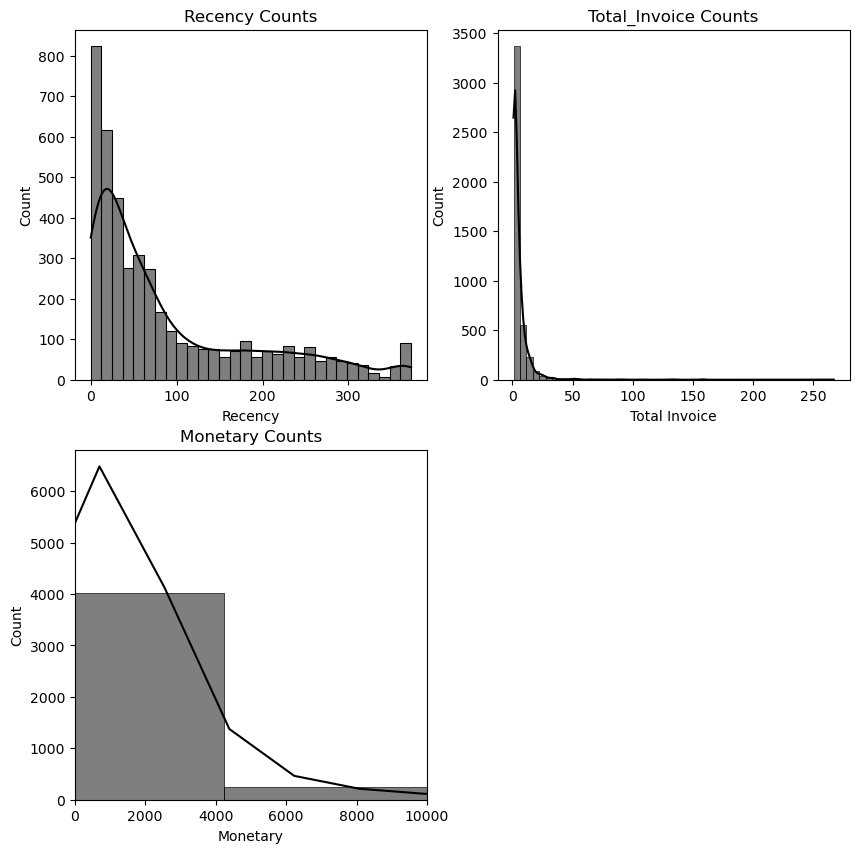

In [168]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.subplot(221)
plt.title("Recency Counts")
sns.histplot(tf["Recency"],bins=30,kde=True,color="black")
plt.subplot(222)
plt.title("Total_Invoice Counts")
sns.histplot(tf["Total Invoice"],bins=50,kde=True,color="black")
plt.subplot(223)
plt.title("Monetary Counts")
sns.histplot(tf["Monetary"],bins=50,kde=True,color="black")
plt.xlim(0,10000)

<Axes: title={'center': 'Outliers in Recency'}, ylabel='Recency'>

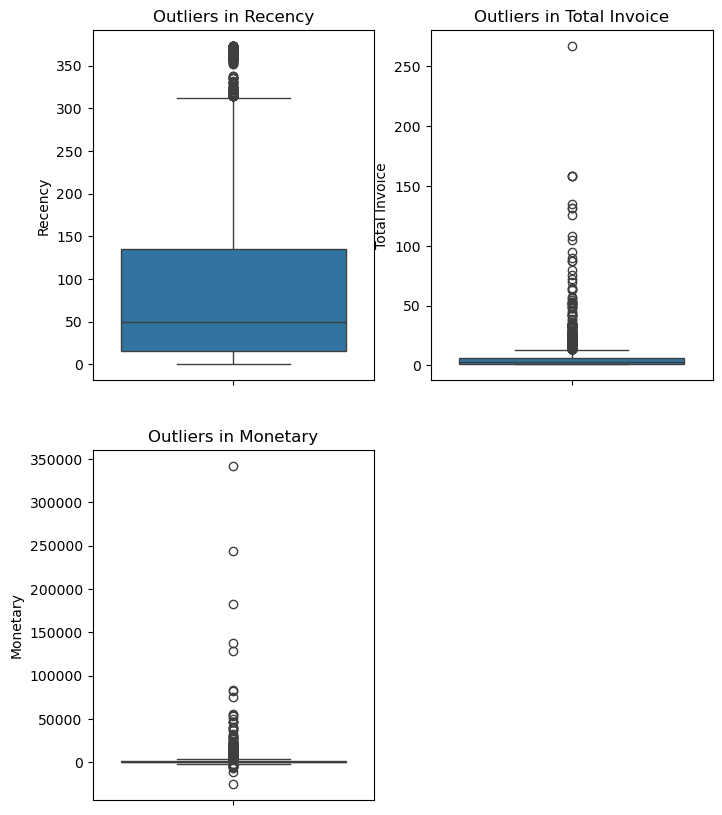

In [169]:
plt.figure(figsize=(8,10))
plt.subplot(222)
plt.title("Outliers in Total Invoice")
sns.boxplot(tf["Total Invoice"])
plt.subplot(223)
plt.title("Outliers in Monetary")
sns.boxplot(tf["Monetary"])
plt.subplot(221)
plt.title("Outliers in Recency")
sns.boxplot(tf["Recency"])

In [170]:
tf[tf["Monetary"]>300000]

,Customer ID,Recency,Total Invoice,Monetary,Avg_expenses_per_invoice,customer_span,gap_days,Potential_Churn
4236,18102.0,0,95,341776.73,3597.65,373,3.970006,0


<Axes: >

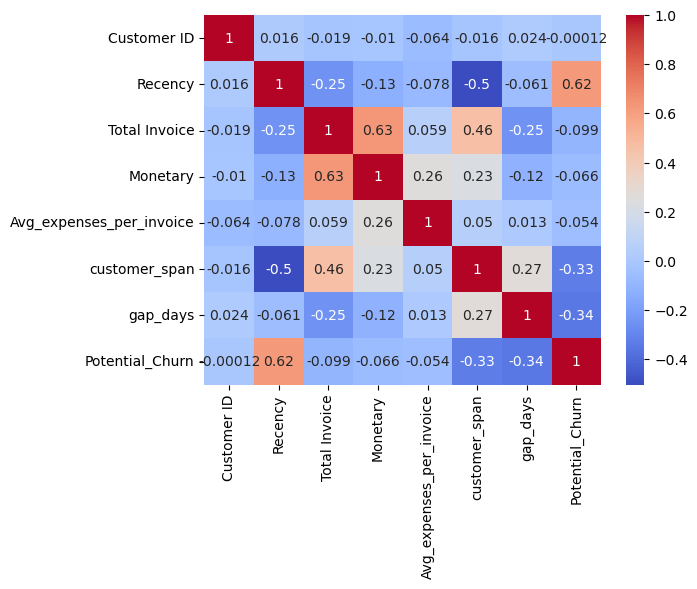

In [171]:
corr=tf.select_dtypes(exclude="object").corr()
sns.heatmap(corr,annot=True,cmap="coolwarm")

**Exploratory Data Analysis (EDA) Insights**

 ***Customer Activity (Recency)***

The distribution of Recency is positively skewed, with a large number of customers making purchases recently, while a smaller group has remained inactive for a long period. This suggests that although a significant portion of customers are still engaged, there exists a noticeable segment of dormant customers that may require retention efforts.

---
 ***Purchase Frequency (Total Invoice)***

The Total Invoice distribution is highly right-skewed. Most customers placed only a few orders, while a small number of customers generated a disproportionately large number of purchases.

This indicates that the business relies on a relatively small group of highly active customers, while the majority of customers purchase infrequently.

---

 ***Customer Spending (Monetary)***

Customer spending also exhibits a strong right-skewed distribution. Most customers contribute a relatively small amount of revenue, whereas a few high-value customers account for a significant share of total sales.

These high-spending customers are not necessarily data errors; instead, they likely represent valuable business customers or highly loyal customers who contribute substantially to overall revenue.

---

 ***Outlier Analysis***

Boxplots reveal the presence of extreme values in both Frequency (Total Invoice) and Monetary Value.

Rather than removing these observations, they were retained because:

- The dataset represents real customer behavior.
- High-frequency and high-spending customers are often the most valuable customers for a business.
- Removing them could result in the loss of important business insights.

Therefore, these observations are treated as genuine customer segments rather than anomalies.

---

 ***Correlation Analysis Insights***

 ***Frequency Drives Revenue***

A strong positive correlation (**0.63**) exists between **Total Invoice** and **Monetary Value**.

This suggests that customers who purchase more frequently tend to generate significantly higher revenue. Increasing repeat purchases may therefore be an effective strategy for improving sales performance.

---

 ***Customer Inactivity and Churn***

Recency shows a strong positive correlation (**0.61**) with the churn indicator.

This confirms that customers who remain inactive for longer periods are more likely to be classified as potential churn customers.

---

 ***Long-Term Customers Are More Engaged***

Customer Span has a moderate negative correlation (**-0.50**) with Recency.

This indicates that customers who maintain a longer relationship with the business generally remain more active and continue purchasing over time.

---

 ***Customer Lifetime and Purchase Frequency***

A positive correlation (**0.46**) exists between Customer Span and Total Invoice.

This suggests that customers who stay with the company longer naturally accumulate more purchases and become more valuable over time.

---

 ***Personalized Churn Logic Captures Customer Behavior***

Average Purchase Gap shows a negative correlation (**-0.36**) with Potential Churn.

This suggests that customers with naturally longer purchase cycles are less likely to be incorrectly classified as churned, demonstrating that the personalized churn framework successfully accounts for individual buying behavior.

---

 ***Revenue Is Influenced More by Frequency Than Order Size***

Average Expense per Invoice shows only weak correlations with most variables.

This indicates that overall revenue growth is driven primarily by how often customers purchase rather than how much they spend in a single order.

---

 **Key Business Findings**

- Most customers make only a small number of purchases.
- Revenue is concentrated among a relatively small group of high-value customers.
- Increasing purchase frequency could have a stronger impact on revenue than increasing average order value.
- Customer inactivity is one of the strongest indicators of potential churn.
- Long-term customers tend to be more engaged and generate more purchases.
- Approximately **26.3% of customers were identified as potential churn customers** using a behavior-based churn framework that incorporates both inactivity and historical purchasing patterns.    

***
***

# **CUSTOMER SEGMENTATION**

In [172]:
from sklearn.cluster import KMeans

In [173]:
tf

,Customer ID,Recency,Total Invoice,Monetary,Avg_expenses_per_invoice,customer_span,gap_days,Potential_Churn
0,12346.0,66,14,51.76,3.70,294,22.640972,1
1,12347.0,2,2,1323.32,661.66,37,37.025694,0
2,12348.0,73,1,222.16,222.16,0,NaN,0
3,12349.0,42,4,2646.99,661.75,327,109.271759,0
4,12351.0,10,1,300.93,300.93,0,NaN,0
...,...,...,...,...,...,...,...,...
4360,18283.0,17,6,619.37,103.23,275,55.185278,0
4361,18284.0,64,2,436.68,218.34,2,2.040278,1
4362,18285.0,295,1,427.00,427.00,0,NaN,1
4363,18286.0,111,3,1188.43,396.14,247,123.525000,0


In [174]:
a=tf["Customer ID"].count()
cluster_df=tf.copy()
cluster_df.drop(columns=["Customer ID","Potential_Churn"],inplace=True)

In [175]:
cluster_df["single_purchase_customer"] = (
    cluster_df["gap_days"].isna()
).astype(int)

cluster_df["gap_days"]=cluster_df["gap_days"].fillna(cluster_df["gap_days"].quantile(0.95))

**Handling Missing Values in Average Purchase Gap**

The `gap_days` feature represents the average number of days between consecutive purchases for each customer.

During feature engineering, it was observed that some customers had missing values (`NaN`) in `gap_days`. These missing values were not caused by data quality issues. Instead, they occurred because certain customers made only a single purchase during the entire observation period. Since no repeat purchase exists for these customers, an average purchase gap cannot be calculated.

Therefore, these missing values contain valuable behavioral information and should not be treated as ordinary missing data.

**Preserving Single-Purchase Behavior**

To retain this information, a new binary feature called `single_purchase_customer` was created.

- `1` → Customer made only one purchase.
- `0` → Customer made multiple purchases.

This feature allows the clustering algorithm to explicitly identify customers who never returned for a repeat purchase.

**Imputation Strategy**

Since K-Means clustering cannot handle missing values, the missing values in `gap_days` needed to be imputed.

Instead of using the median purchase gap, a high purchase-gap benchmark (95th percentile of observed purchase gaps) was used. This approach better represents customers who have not demonstrated repeat purchasing behavior.

Using the median would incorrectly suggest that single-purchase customers behave similarly to average returning customers. Assigning a large purchase-gap value more accurately reflects their uncertain or potentially inactive status.

**Final Approach**

The final preprocessing strategy consisted of:

1. Creating a `single_purchase_customer` indicator feature.
2. Replacing missing `gap_days` values with the 95th percentile of observed purchase gaps.
3. Retaining both features for customer segmentation and clustering.

This approach preserves important customer behavior patterns while ensuring that the dataset remains suitable for machine learning algorithms.

In [176]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
df_cluster=scale.fit_transform(cluster_df)

In [177]:
# Applying Elbow Method
wcss=[]
for i in range(1,50):
    clf=KMeans(n_clusters=i,random_state=42,n_init=10)
    clf.fit_predict(df_cluster)
    wcss.append(clf.inertia_)
    

In [178]:
wcss

[30555.000000000007,
 20843.933039033716,
 17078.620084587805,
 13961.880884290718,
 12034.806030262365,
 10609.086879441762,
 8970.744590543585,
 7715.622180227893,
 6767.929158015624,
 5912.588965085254,
 5241.5205246776295,
 4799.46824004827,
 4473.835156002744,
 4222.2874473927695,
 3936.057022386175,
 3702.7860429420157,
 3537.580073393592,
 3268.695143407288,
 3070.724449006713,
 2932.1762612482225,
 2790.495598867959,
 2664.8019287774496,
 2583.0818180225024,
 2442.128444420157,
 2402.8368292388004,
 2251.260343758016,
 2203.1752069997297,
 2113.9863319374876,
 2043.315410943658,
 1979.4928079517808,
 1935.7446381809204,
 1870.4790467459889,
 1804.598932357017,
 1755.393547461698,
 1711.692805955061,
 1670.603152207785,
 1638.5073905652828,
 1591.188443183401,
 1523.6874245877962,
 1500.0330972676306,
 1467.8666358937583,
 1438.1954603699635,
 1410.6018979079593,
 1389.549413087175,
 1370.8292808750111,
 1341.0919899421983,
 1296.3951993279907,
 1278.7574392680938,
 1252.4239937

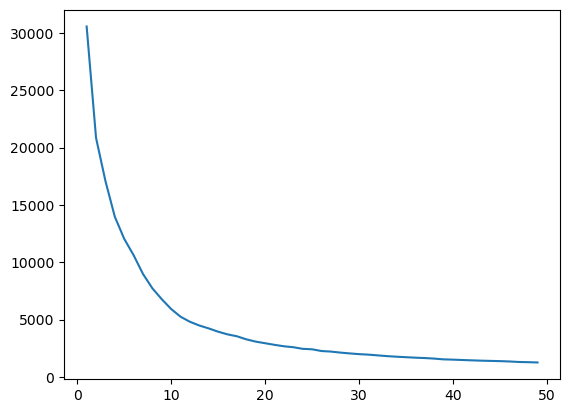

In [179]:
plt.plot(range(1,50),wcss)

In [180]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

scores = []

for k in range(2,11):
    km = KMeans(n_clusters=k, random_state=42,n_init=10)
    labels = km.fit_predict(df_cluster)

    score = silhouette_score(df_cluster, labels)

    scores.append(score)

    print(k, score)

2 0.4699491197420013
3 0.4770744367361438
4 0.37574610439662626
5 0.3783443819719114
6 0.38342669594593815
7 0.3924182294934231
8 0.40106193638200877
9 0.41152056636632445
10 0.4162638218502263


Text(0, 0.5, 'Silhouette Score')

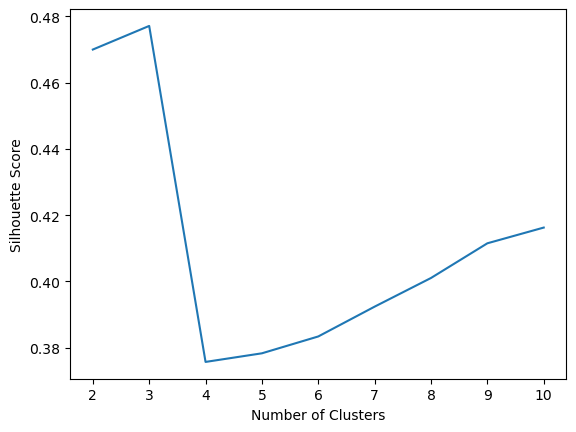

In [181]:
plt.plot(range(2,11), scores)
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

In [182]:
tf["Cluster"]=KMeans(n_clusters=8,random_state=42,n_init=10).fit_predict(df_cluster)

In [183]:
tf

,Customer ID,Recency,Total Invoice,Monetary,Avg_expenses_per_invoice,customer_span,gap_days,Potential_Churn,Cluster
0,12346.0,66,14,51.76,3.70,294,22.640972,1,0
1,12347.0,2,2,1323.32,661.66,37,37.025694,0,2
2,12348.0,73,1,222.16,222.16,0,NaN,0,1
3,12349.0,42,4,2646.99,661.75,327,109.271759,0,6
4,12351.0,10,1,300.93,300.93,0,NaN,0,1
...,...,...,...,...,...,...,...,...,...
4360,18283.0,17,6,619.37,103.23,275,55.185278,0,0
4361,18284.0,64,2,436.68,218.34,2,2.040278,1,2
4362,18285.0,295,1,427.00,427.00,0,NaN,1,5
4363,18286.0,111,3,1188.43,396.14,247,123.525000,0,6


In [184]:
tf.groupby("Cluster").agg({
    "Customer ID":"count",
    "Recency":"mean",
    "Total Invoice":"mean",
    "Monetary":"mean",
    "Avg_expenses_per_invoice":"mean",
    "customer_span":"mean",
    "gap_days":"mean",
    "Potential_Churn":"mean"
}).round(2)

,Customer ID,Recency,Total Invoice,Monetary,Avg_expenses_per_invoice,customer_span,gap_days,Potential_Churn
Cluster,,,,,,,,
0,1255,27.16,10.36,3323.34,317.46,290.81,41.60,0.09
1,694,60.74,1.00,349.22,349.22,0.00,NaN,0.00
2,1260,105.91,3.48,923.14,269.82,69.19,31.47,0.59
3,5,4.60,137.20,206717.77,1903.70,367.00,3.17,0.00
4,1,175.00,1.00,-25111.09,-25111.09,0.00,NaN,0.00
5,558,267.78,1.00,185.44,185.44,0.00,NaN,0.54
6,554,55.70,2.72,859.48,317.02,235.64,153.81,0.00
7,38,8.82,70.74,30202.07,512.59,355.97,6.13,0.05


**Determining the Optimal Number of Clusters**

Before performing customer segmentation, it was necessary to determine the appropriate number of clusters (K) for the K-Means algorithm. Two commonly used techniques were employed: the Elbow Method and the Silhouette Score.

**Elbow Method**

The Elbow Method evaluates how the Within-Cluster Sum of Squares (WCSS) decreases as the number of clusters increases.

The WCSS curve showed a steep decline during the initial cluster additions, indicating that each new cluster significantly improved the grouping of customers. However, after approximately 8–10 clusters, the rate of improvement began to slow down considerably, suggesting diminishing returns from adding additional clusters.

This indicates that the natural cluster structure of the customer base likely lies within this range.

**Silhouette Analysis**

To validate the cluster selection, Silhouette Scores were calculated for values of K ranging from 2 to 10.

The highest score was observed at K=2, indicating the strongest separation between clusters. However, a two-cluster solution would provide limited business value, as it would likely divide customers into only broad groups rather than meaningful customer segments.

Interestingly, the Silhouette Score improved again for higher values of K and remained above 0.40 for K=8, K=9, and K=10, indicating reasonably wellseparated clusters while allowing for more detailed customer segmentation.

**Final Cluster Selection**

The final value of K was selected as **8** based on the following considerations:

- Supported by the elbow region observed in the WCSS curve.
- Achieved a strong Silhouette Score (greater than 0.40).
- Provides sufficient granularity to identify different customer behaviors.
- Produces customer segments that are easier to interpret and translate into business strategies.

Rather than selecting the value that simply maximized a statistical metric, the final decision balanced both clustering quality and business interpretability.

This approach ensures that the resulting customer segments are not only mathematically meaningful but also useful for business decisionmaking and customer retention strategies.

In [185]:
tf

,Customer ID,Recency,Total Invoice,Monetary,Avg_expenses_per_invoice,customer_span,gap_days,Potential_Churn,Cluster
0,12346.0,66,14,51.76,3.70,294,22.640972,1,0
1,12347.0,2,2,1323.32,661.66,37,37.025694,0,2
2,12348.0,73,1,222.16,222.16,0,NaN,0,1
3,12349.0,42,4,2646.99,661.75,327,109.271759,0,6
4,12351.0,10,1,300.93,300.93,0,NaN,0,1
...,...,...,...,...,...,...,...,...,...
4360,18283.0,17,6,619.37,103.23,275,55.185278,0,0
4361,18284.0,64,2,436.68,218.34,2,2.040278,1,2
4362,18285.0,295,1,427.00,427.00,0,NaN,1,5
4363,18286.0,111,3,1188.43,396.14,247,123.525000,0,6


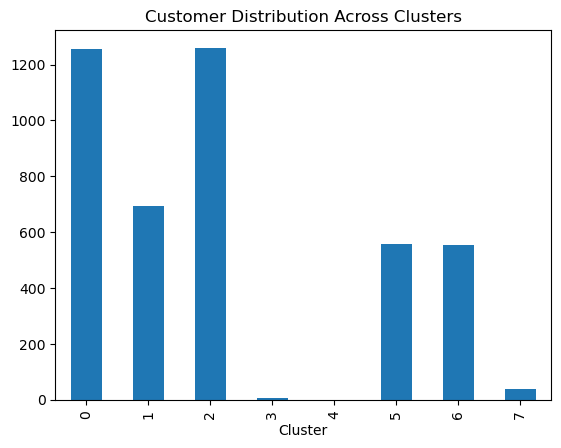

In [186]:
tf["Cluster"].value_counts().sort_index().plot(
    kind="bar"
)
plt.title("Customer Distribution Across Clusters")
plt.show()

In [198]:
segment_map = {
    0: "High-Value Repeat Customers",
    1: "Recent One-Time Buyers",
    2: "At-Risk Customers",
    3: "Enterprise Customers",
    4: "Data Outlier",
    5: "Lost One-Time Buyers",
    6: "Regular Active Customers",
    7: "VIP Customers"
}

tf["Segment"] = tf["Cluster"].map(segment_map)

In [199]:
tf

,Customer ID,Recency,Total Invoice,Monetary,Avg_expenses_per_invoice,customer_span,gap_days,Potential_Churn,Cluster,Segment
0,12346.0,66,14,51.76,3.70,294,22.640972,1,0,High-Value Repeat Customers
1,12347.0,2,2,1323.32,661.66,37,37.025694,0,2,At-Risk Customers
2,12348.0,73,1,222.16,222.16,0,NaN,0,1,Recent One-Time Buyers
3,12349.0,42,4,2646.99,661.75,327,109.271759,0,6,Regular Active Customers
4,12351.0,10,1,300.93,300.93,0,NaN,0,1,Recent One-Time Buyers
...,...,...,...,...,...,...,...,...,...,...
4360,18283.0,17,6,619.37,103.23,275,55.185278,0,0,High-Value Repeat Customers
4361,18284.0,64,2,436.68,218.34,2,2.040278,1,2,At-Risk Customers
4362,18285.0,295,1,427.00,427.00,0,NaN,1,5,Lost One-Time Buyers
4363,18286.0,111,3,1188.43,396.14,247,123.525000,0,6,Regular Active Customers


In [200]:
churn_customer_count=tf[tf["Potential_Churn"]==1].groupby("Segment")["Potential_Churn"].value_counts().reset_index()
customer_count_per_cluster=tf.groupby("Segment")["Customer ID"].count()
churn_customer_count=pd.merge(churn_customer_count,customer_count_per_cluster,on="Segment",how="left")
churn_customer_count

,Segment,Potential_Churn,count,Customer ID
0,At-Risk Customers,1,746,1260
1,High-Value Repeat Customers,1,107,1255
2,Lost One-Time Buyers,1,301,558
3,Regular Active Customers,1,1,554
4,VIP Customers,1,2,38


**Customer Segmentation Analysis**

**Objective**

Customer segmentation was performed to group customers with similar purchasing behaviors into meaningful business segments. These segments help identify high-value customers, customers at risk of churn, and potential growth opportunities, enabling more targeted business and marketing strategies.

---

**Features Used for Clustering**

The following customer-level features were used for segmentation:

* **Recency** – Days since last purchase
* **Total Invoice (Frequency)** – Total number of orders placed
* **Monetary Value** – Total customer spending
* **Average Expense per Invoice** – Average order value
* **Customer Span** – Days between first and last purchase
* **Average Purchase Gap** – Average days between consecutive purchases

All features were standardized prior to clustering to ensure equal contribution to distance calculations.

---

**Determining the Number of Clusters**

**Elbow Method**

The Elbow Method was applied using Within-Cluster Sum of Squares (WCSS). The curve showed a noticeable reduction in improvement after approximately 8 clusters, indicating diminishing returns from adding additional clusters.

**Silhouette Analysis**

Silhouette scores were calculated for different values of K to evaluate cluster cohesion and separation. While smaller values of K produced slightly higher silhouette scores, an 8-cluster solution provided a better balance between statistical performance and business interpretability.

---

**Final Clustering Model**

The final segmentation model was built using:

```python
KMeans(
    n_clusters=8,
    random_state=42,
    n_init=10
)
```

A fixed random state was used to ensure reproducible results across notebook executions.

---

**Customer Segment Profiles**

**Segment 1: High-Value Repeat Customers**

**Characteristics**

* High purchase frequency
* Strong spending behavior
* Long customer relationship duration
* Low churn rate

**Business Interpretation**

These customers contribute significant revenue and have historically demonstrated strong engagement with the business. They represent one of the most valuable customer groups and should be prioritized for retention.

**Recommended Actions**

* Loyalty programs
* Personalized promotions
* Retention campaigns

---

**Segment 2: Recent One-Time Buyers**

**Characteristics**

* Single purchase customers
* Recently acquired
* Low spending levels
* Low churn risk

**Business Interpretation**

These customers have only made one purchase but are still within a reasonable period to return. They represent an opportunity to increase repeat purchase rates.

**Recommended Actions**

* Welcome campaigns
* Product recommendations
* First-to-second purchase incentives

---

**Segment 3: At-Risk Customers**

**Characteristics**

* Moderate purchase frequency
* Moderate spending levels
* High inactivity relative to historical purchase behavior
* Highest churn concentration among repeat customers

**Business Interpretation**

These customers were previously active but have not returned within their expected purchase cycle. This segment represents the most important retention opportunity.

**Recommended Actions**

* Win-back campaigns
* Personalized discounts
* Re-engagement communications

---

**Segment 4: Enterprise Customers**

**Characteristics**

* Extremely high order frequency
* Exceptionally high spending levels
* Very low churn behavior

**Business Interpretation**

Although small in size, this segment generates a disproportionately large share of revenue and represents strategic business customers.

**Recommended Actions**

* Dedicated account management
* Premium support
* Customized business offers

---

**Segment 5: Data Outlier**

**Characteristics**

* Unusual transaction patterns
* Negative monetary values observed
* Very small segment size

**Business Interpretation**

This segment likely reflects refunds, returns, credit notes, or exceptional transaction behavior rather than a true customer segment.

**Recommended Actions**

* Data quality review
* Separate investigation
* Exclusion from marketing segmentation if required

---

**Segment 6: Lost One-Time Buyers**

**Characteristics**

* Single purchase customers
* Long inactivity period
* High churn rate

**Business Interpretation**

These customers made only one purchase and have remained inactive for a substantial period. They are likely lost customers.

**Recommended Actions**

* Aggressive win-back campaigns
* Promotional incentives
* Customer feedback collection

---

**Segment 7: Regular Active Customers**

**Characteristics**

* Moderate purchase frequency
* Consistent spending patterns
* Long customer lifespan
* Very low churn rate

**Business Interpretation**

These customers represent the stable core of the customer base. They purchase periodically and remain actively engaged with the business.

**Recommended Actions**

* Loyalty rewards
* Cross-selling initiatives
* Ongoing engagement campaigns

---

**Segment 8: VIP Customers**

**Characteristics**

* Extremely high spending levels
* Very high purchase frequency
* Recent purchase activity
* Minimal churn risk

**Business Interpretation**

Although this segment contains relatively few customers, it contributes substantial revenue and represents the company's most valuable customer group.

**Recommended Actions**

* VIP membership programs
* Exclusive offers
* Premium customer experiences

---

**Key Business Insights**

The segmentation analysis identified distinct customer groups with significantly different purchasing behaviors and churn tendencies.

Key observations include:

* **At-Risk Customers** and **Lost One-Time Buyers** account for the largest proportion of potential churn customers.
* **VIP Customers** and **Enterprise Customers** generate substantial revenue while exhibiting minimal churn risk.
* **Recent One-Time Buyers** represent an important growth opportunity through repeat purchase conversion strategies.
* **Regular Active Customers** and **High-Value Repeat Customers** form the foundation of the customer base and should be continuously nurtured through retention programs.

The resulting segments provide a practical framework for customer retention, targeted marketing, customer lifetime value optimization, and strategic business decision-making.
